Installations

In [ ]:
# Check Colab virtual memory
!du -h --max-depth=1 /content

140K	/content/.config
9.8G	/content/drive
55M	/content/sample_data
9.9G	/content


In [2]:
# Upgrade pip
!pip install --upgrade pip

# Install PyTorch/XLA for TPU
!pip install torch torchvision torchaudio torch_xla --extra-index-url https://storage.googleapis.com/pytorch-tpu-releases/wheels/tpuvm/torch_xla-2.8

# Upgrade Hugging Face and other dependencies
!pip install --upgrade diffusers transformers accelerate safetensors datasets huggingface_hub peft opencv-python-headless python-dotenv

# Performance metrics
!pip install scikit-image torchmetrics[image] torch-fidelity pytorch-fid


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://pypi.org/simple, https://storage.googleapis.com/pytorch-tpu-releases/wheels/tpuvm/torch_xla-2.8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 55.0 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 30.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 52.1 MB/s  0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Unins

In [3]:
# Verify diffusers version
import diffusers
print(diffusers.__version__)

0.35.2


Libraries

In [4]:
import torch
# Colorizer-------------------
from diffusers import StableDiffusionImg2ImgPipeline
# Inpainting ---------------
from diffusers import StableDiffusionInpaintPipeline
# ----------------------------------------
from google.colab import drive
import os
from dotenv import load_dotenv
from datasets import load_dataset
from huggingface_hub import login

# Preprocessing, data handling
from sklearn.model_selection import train_test_split

# Visualizations
import cv2
from PIL import Image, ImageDraw
from IPython.display import display
import matplotlib.pyplot as plt

# Colorizer fine tuning
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, AutoencoderKL, DDPMScheduler, PNDMScheduler
from diffusers.models.attention_processor import LoRAAttnProcessor
from diffusers.optimization import get_scheduler

from transformers import CLIPTextModel, CLIPTokenizer, CLIPVisionModel, CLIPImageProcessor

from accelerate import Accelerator
from torchvision import transforms
from peft import LoraConfig, get_peft_model_state_dict, get_peft_model
from torch import nn, optim
from tqdm import tqdm

# LoRA prep
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
# Performance metrics
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from torchmetrics.image.fid import FrechetInceptionDistance





/usr/local/lib/python3.12/dist-packages/torch_xla/__init__.py:246: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Env file path
env_path = "/content/drive/MyDrive/AAI-521 Final Project/hf_login.env"
# Open env file
load_dotenv(env_path)
# Access token from environment
hf_key = os.getenv("HF_TOKEN")
print("HF key loaded:", hf_key is not None)

# Dataset Paths

# ------------------------------------------
# Inpainting - Dataset Paths
# ------------------------------------------

# 1) Paths for inpaint ds train/val/test img subsets
INPAINT_DATA_ROOT = "/content/drive/MyDrive/AAI-521 Final Project/inpainting_subset"
INPAINT_SPLIT_DIRS = {
    "train": os.path.join(INPAINT_DATA_ROOT, "train"),
    "val":   os.path.join(INPAINT_DATA_ROOT, "val"),
    "test":  os.path.join(INPAINT_DATA_ROOT, "test"),
}

# 2) Create ds dirs
os.makedirs(INPAINT_DATA_ROOT, exist_ok=True)
for d in INPAINT_SPLIT_DIRS.values():
    os.makedirs(d, exist_ok=True)
    os.makedirs(os.path.join(d, "masked"), exist_ok=True)
    os.makedirs(os.path.join(d, "original"), exist_ok=True)

# 3) Path to FT inpaint model
INPAINT_FINE_MODEL_SAVE_DIR = "/content/drive/MyDrive/AAI-521 Final Project/fine_tuned_models/inpainting"
# Make sure it exists
os.makedirs(INPAINT_FINE_MODEL_SAVE_DIR, exist_ok=True)

# 4) Ensure test_images folder exists
os.makedirs("/content/drive/MyDrive/AAI-521 Final Project/test_images", exist_ok=True)
# 5) inpaint test image path
inpaint_image_path = "/content/drive/MyDrive/AAI-521 Final Project/test_images/inpaint_ex1.png"
# 6) inpaint true color test image
true_color_image_path = "/content/drive/MyDrive/AAI-521 Final Project/test_images/true_color_ex1.png"


# 7) Subfolder for pipeline
# Updated - use inpainting subfolder
INPAINT_PIPELINE_DIR = os.path.join(INPAINT_FINE_MODEL_SAVE_DIR, "inpainting_pipeline")
os.makedirs(INPAINT_PIPELINE_DIR, exist_ok=True)
# 8) Inpaint checkpoint path
inpaint_ckpt_path = "/content/drive/MyDrive/AAI-521 Final Project/fine_tuned_models/inpainting/best_unet.pth"


HF key loaded: True


Load COCO dataset

In [ ]:
coco_ds = load_dataset("detection-datasets/coco")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00040-67e35002d15215(…):   0%|          | 0.00/485M [00:00<?, ?B/s]

...

data/val-00000-of-00002-c4f2e391ee4aba11(…):   0%|          | 0.00/404M [00:00<?, ?B/s]

data/val-00001-of-00002-7af5414a3b178949(…):   0%|          | 0.00/404M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117266 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4952 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
# # Full COCO dataset
coco_ds

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 117266
    })
    val: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 4952
    })
})

In [ ]:
# Check Colab virtual memory
!du -h --max-depth=1 /content

140K	/content/.config
11G	/content/drive
55M	/content/sample_data
11G	/content


# Filter COCO ds for 1500 color images

In [ ]:
# Confirm color
def is_color(pil_img):
    if pil_img.mode != "RGB":
        return False
    r, g, b = pil_img.split()
    return not (r == g == b)

color_images = []
max_needed = 1500

# Only use existing splits: train and val
for split in ["train", "val"]:
    for row in coco_ds[split]:

        img = row["image"]  # already a PIL image

        try:
            img = img.convert("RGB")
        except:
            continue

        if not is_color(img):
            continue

        color_images.append(img)

        if len(color_images) >= max_needed:
            break

    if len(color_images) >= max_needed:
        break

len(color_images)

1500

# Create Mask Pairs

In [ ]:
import numpy as np
from PIL import Image, ImageDraw
import random

def apply_rectangle_mask(img, max_area_frac=0.25, max_rects=3):
    w, h = img.size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    for _ in range(random.randint(1, max_rects)):
        area = random.uniform(0.02, max_area_frac)
        rect_w = int(w * (area ** 0.5) * random.uniform(0.5, 1.5))
        rect_h = int(h * (area ** 0.5) * random.uniform(0.5, 1.5))

        x1 = random.randint(0, max(0, w - rect_w))
        y1 = random.randint(0, max(0, h - rect_h))

        draw.rectangle([x1, y1, x1 + rect_w, y1 + rect_h], fill=255)

    # apply mask
    masked = img.copy()
    arr = np.array(masked)
    mask_np = np.array(mask)
    arr[mask_np == 255] = 0  # black masked pixels

    return Image.fromarray(arr), mask

# -----------------------------------------
# Create (masked_img, original_img) pairs
# -----------------------------------------
pairs = []

for img in color_images:
    original = img.resize(IMG_SIZE, resample=Image.LANCZOS)

    masked, _ = apply_rectangle_mask(original)

    pairs.append((masked, original))

print(len(pairs))
print('Splitting datasets for train, val, test...')

train_pairs, temp_pairs = train_test_split(pairs, test_size=0.30, random_state=42)
val_pairs, test_pairs   = train_test_split(temp_pairs, test_size=0.50, random_state=42)

print(f"Dataset images count (train/val/test): {len(train_pairs), len(val_pairs), len(test_pairs)}")

# -----------------------------------------
# Save images
# -----------------------------------------
print('Saving images (train/val/test)...')

for split_name, split_pairs in [
    ("train", train_pairs),
    ("val", val_pairs),
    ("test", test_pairs),
]:
    out_dir = INPAINT_SPLIT_DIRS[split_name]

    masked_dir = os.path.join(out_dir, "masked")
    orig_dir   = os.path.join(out_dir, "original")

    os.makedirs(masked_dir, exist_ok=True)
    os.makedirs(orig_dir, exist_ok=True)

    for i, (masked_img, original_img) in enumerate(split_pairs):
        masked_img.save(os.path.join(masked_dir, f"{i:05d}.png"))
        original_img.save(os.path.join(orig_dir, f"{i:05d}.png"))


1500
Splitting datasets for train, val, test...
Dataset images count (train/val/test): (1050, 225, 225)
Saving images (train/val/test)...


# Visualize mask pairs

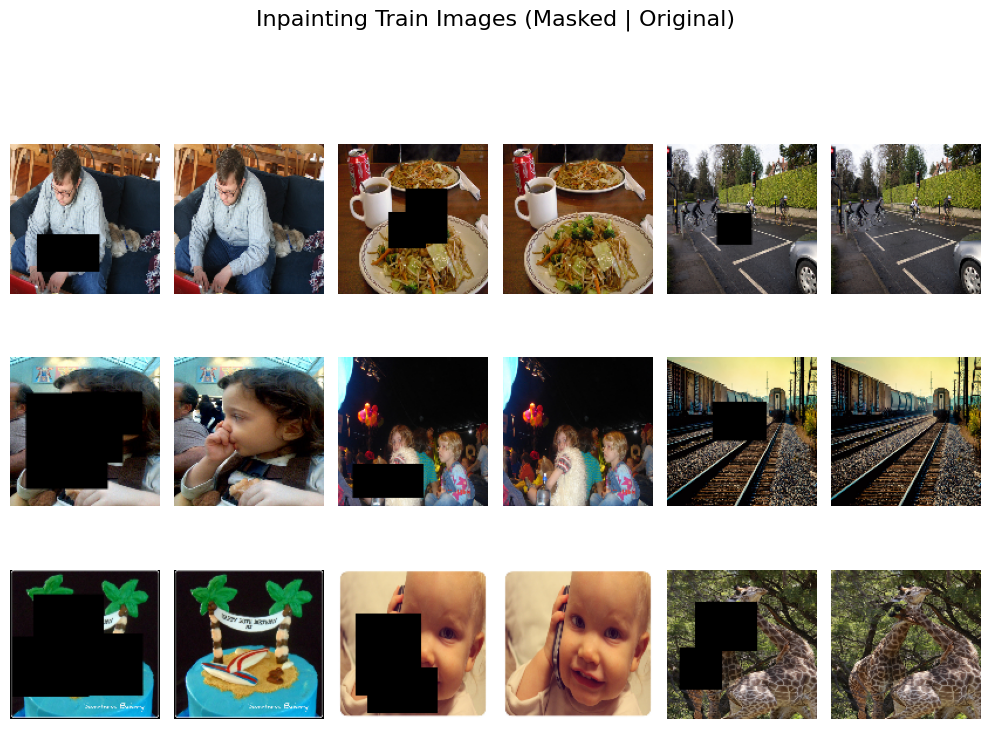

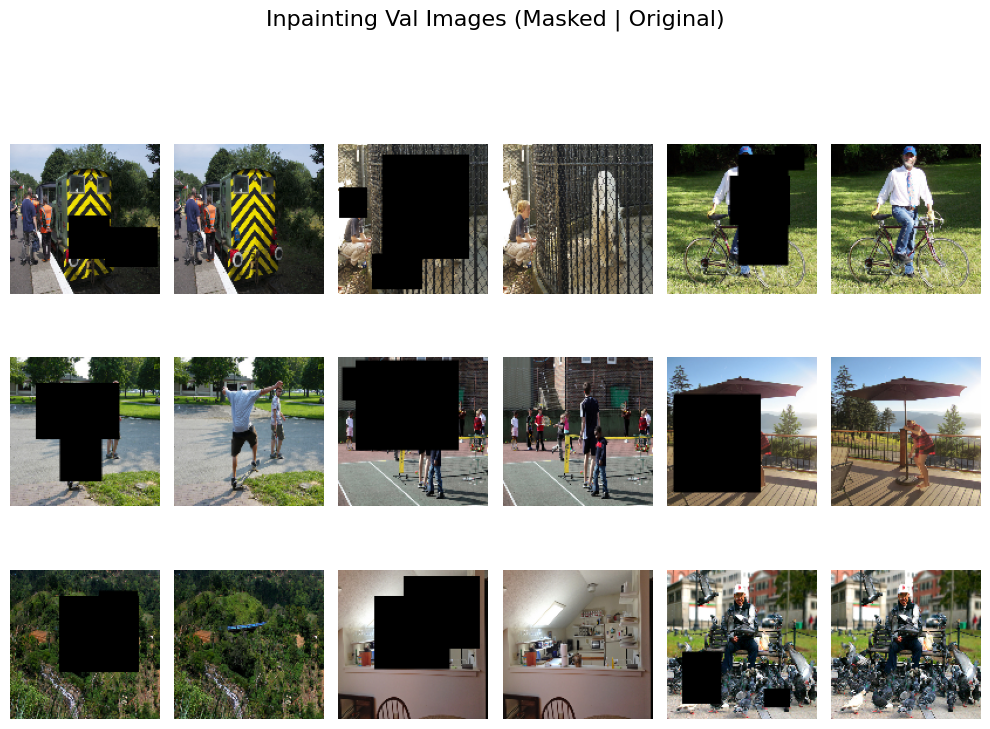

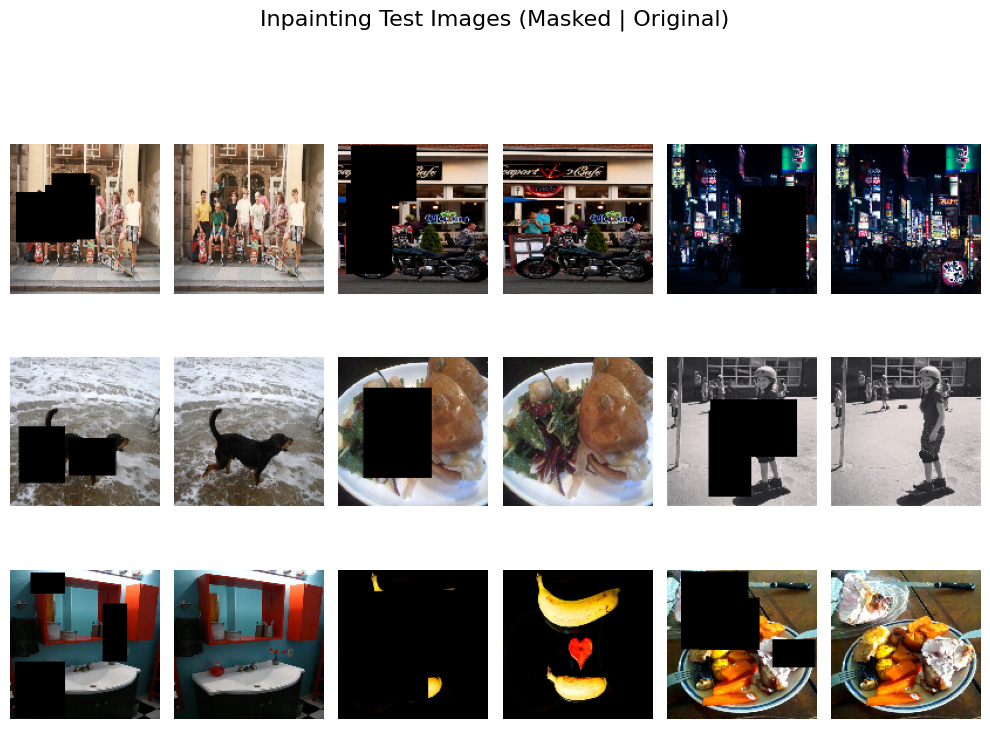

In [ ]:
splits = ["train", "val", "test"]

for split_name in splits:
    masked_dir = os.path.join(INPAINT_SPLIT_DIRS[split_name], "masked")
    orig_dir   = os.path.join(INPAINT_SPLIT_DIRS[split_name], "original")

    # First 9 images
    image_files = sorted(os.listdir(orig_dir))[:9]

    # Load & resize
    masked_images = [
        cv2.resize(cv2.imread(os.path.join(masked_dir, f)), (128,128))
        for f in image_files
    ]
    orig_images = [
        cv2.resize(cv2.imread(os.path.join(orig_dir, f)), (128,128))
        for f in image_files
    ]

    # Plot
    plt.figure(figsize=(10, 8))
    plt.suptitle(f"Inpainting {split_name.capitalize()} Images (Masked | Original)", fontsize=16)

    for i in range(9):
        # Masked image
        plt.subplot(3, 6, 2*i+1)
        plt.imshow(cv2.cvtColor(masked_images[i], cv2.COLOR_BGR2RGB))
        plt.axis('off')

        # Original
        plt.subplot(3, 6, 2*i+2)
        plt.imshow(cv2.cvtColor(orig_images[i], cv2.COLOR_BGR2RGB))
        plt.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Test - verify mask region detection from masked image dataset

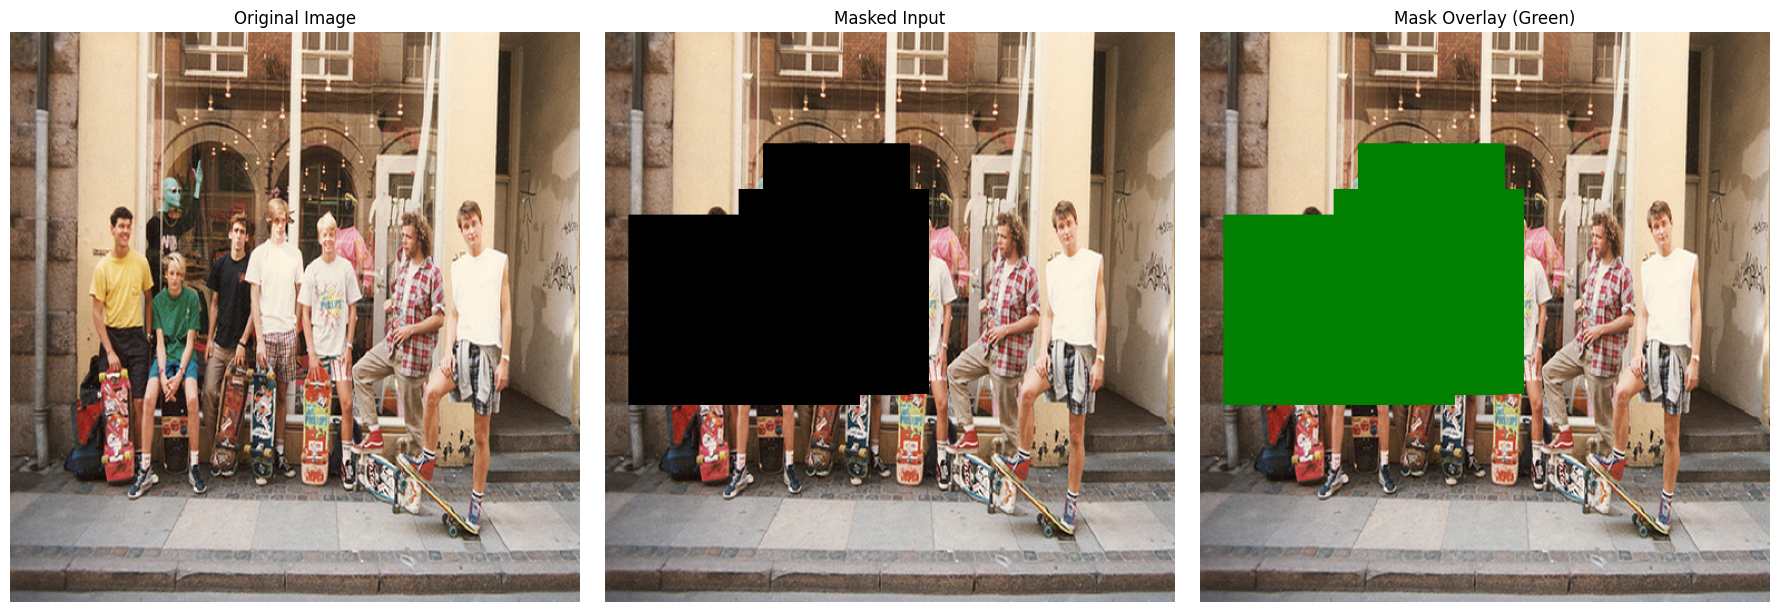

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --------------------------
# SETTINGS
# --------------------------
resize_shape = (512, 512)

def resize_before(pil_img):
    if pil_img.mode != "RGB":
        pil_img = pil_img.convert("RGB")
    return pil_img.resize(resize_shape)

# --------------------------
# LOAD ONE TEST IMAGE AND MASK
# --------------------------
test_mask_dir = os.path.join(INPAINT_SPLIT_DIRS["test"], "masked")
test_orig_dir = os.path.join(INPAINT_SPLIT_DIRS["test"], "original")
test_files = sorted(os.listdir(test_mask_dir))[:1]  # just one image

orig = Image.open(os.path.join(test_orig_dir, test_files[0])).convert("RGB")
masked = Image.open(os.path.join(test_mask_dir, test_files[0])).convert("RGB")

orig_resized = resize_before(orig)
masked_resized = resize_before(masked)

# --------------------------
# CREATE GREEN OVERLAY
# --------------------------
orig_arr = np.array(orig_resized)
masked_arr = np.array(masked_resized)
mask_bin = ((orig_arr != masked_arr).any(axis=2))

overlay = np.array(masked_resized).copy()
overlay[mask_bin] = [0, 255, 0]  # green

alpha = 0.5
blended = (np.array(masked_resized) * (1 - alpha) + overlay * alpha).astype(np.uint8)

# --------------------------
# DISPLAY SUBPLOTS
# --------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(orig_resized)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(masked_resized)
axes[1].set_title("Masked Input")
axes[1].axis("off")

axes[2].imshow(blended)
axes[2].set_title("Mask Overlay (Green)")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# Single test run inference with base model

In [10]:
inpaint_prompt = "fill in the missing part of the image realistically"

In [ ]:
# Load base model again
inpaint_base_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    safety_checker = None # Disabled to avoid false errors with proper usage
)

- Identifies pixels where the masked image differs from the original.

- Creates a single-channel binary mask: 255 for pixels to inpaint, 0 for pixels to keep.

- Fills the masked regions in the input image with white (255,255,255)

- Prepares the filled image (RGB) and the binary mask (L mode) for input to the inpainting pipeline.

  0%|          | 0/50 [00:00<?, ?it/s]

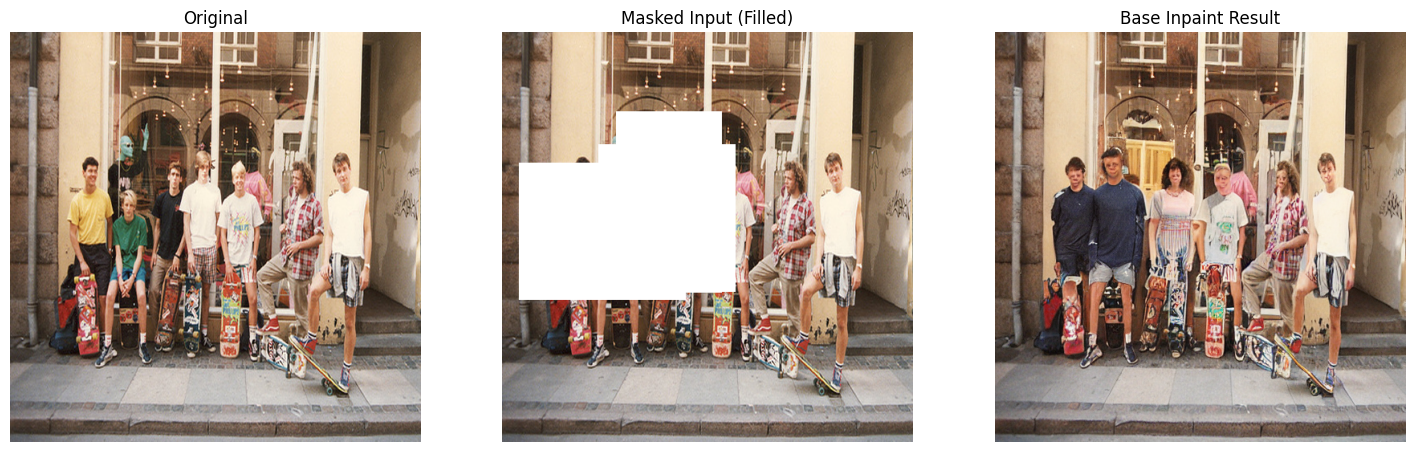

In [12]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

resize_shape = (512, 512)

def resize_before(pil_img):
    if pil_img.mode != "RGB":
        pil_img = pil_img.convert("RGB")
    return pil_img.resize(resize_shape)

# --------------------------
# LOAD TEST IMAGES AND MASKS
# --------------------------
test_mask_dir = os.path.join(INPAINT_SPLIT_DIRS["test"], "masked")
test_orig_dir = os.path.join(INPAINT_SPLIT_DIRS["test"], "original")
test_files = sorted(os.listdir(test_mask_dir))[:3]

dataset_masked_imgs = []
dataset_original_imgs = []
dataset_binary_masks = []

for f in test_files:
    # Load images
    orig = Image.open(os.path.join(test_orig_dir, f)).convert("RGB")
    masked = Image.open(os.path.join(test_mask_dir, f)).convert("RGB")

    orig_resized = resize_before(orig)
    masked_resized = resize_before(masked)

    dataset_original_imgs.append(orig_resized)

    # --- Create RGB mask: black background, white for inpaint ---
    masked_arr = np.array(masked_resized)
    orig_arr = np.array(orig_resized)

    # Detect different pixels in masked image
    mask_arr = ((orig_arr != masked_arr).any(axis=2)).astype(np.uint8) * 255

    # Convert to single-channel L
    binary_mask = Image.fromarray(mask_arr).convert("L")


    # Append binary_mask to the dataset_binary_mask
    dataset_binary_masks.append(binary_mask)

    # --- Fill masked area with white in the masked image ---
    masked_arr[mask_arr == 255] = [255, 255, 255]
    filled_masked_img = Image.fromarray(masked_arr)
    dataset_masked_imgs.append(filled_masked_img)

# Pick first image for demo
masked_img = dataset_masked_imgs[0]
mask_img = dataset_binary_masks[0]  # 255 = inpaint, 0 = keep
orig_img = dataset_original_imgs[0]

# ---- Run Stable Diffusion Inpainting ----
base_result = inpaint_base_pipe(
    prompt=inpaint_prompt,
    image=masked_img,
    mask_image=mask_img,
    generator=torch.manual_seed(42)
).images[0]

# --------------------------
# DISPLAY
# --------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(orig_img)
axes[0].set_title("Original True Image")
axes[0].axis("off")

axes[1].imshow(masked_img)
axes[1].set_title("Masked Input (Filled with white)")
axes[1].axis("off")

axes[2].imshow(base_result)
axes[2].set_title("Base Inpaint Result")
axes[2].axis("off")

plt.show()


# Inpainting Fine tuning Dataset and UNet preparation
- train and val loader
- Inject LoRA into base pipeline UNet

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os
import numpy as np
from torchvision import transforms as T

from diffusers import (
    StableDiffusionInpaintPipeline,
    UNet2DConditionModel,
    AutoencoderKL,
    PNDMScheduler,
)
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model

# Transform for masked/original images
img_transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)  # scale to [-1,1] for Stable Diffusion
])

# Transform for masks
mask_transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor()  # will convert 0/255 to 0.0/1.0
])

class InpaintingDataset(Dataset):
    def __init__(self, masked_dir, orig_dir, transform=None, mask_transform=None):
        self.masked_files = sorted(os.listdir(masked_dir))
        self.orig_files   = sorted(os.listdir(orig_dir))
        self.masked_dir = masked_dir
        self.orig_dir   = orig_dir
        self.transform = transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.masked_files)

    def __getitem__(self, idx):
        masked = Image.open(os.path.join(self.masked_dir, self.masked_files[idx])).convert("RGB")
        orig   = Image.open(os.path.join(self.orig_dir,   self.orig_files[idx])).convert("RGB")

        # auto-build binary mask from black pixels
        masked_np = np.array(masked)
        mask_np = (masked_np.sum(axis=2) == 0).astype(np.uint8)  # shape H,W

        mask_img = Image.fromarray(mask_np * 255)  # convert to PIL for transform

        if self.transform:
            masked = self.transform(masked)
            orig   = self.transform(orig)

        if self.mask_transform:
            mask = self.mask_transform(mask_img)
        else:
            mask = T.ToTensor()(mask_img)

        return {
            "masked": masked,    # 3×512×512
            "mask":   mask,      # 1×512×512 (0 or 1)
            "orig":   orig       # 3×512×512
        }
train_dataset = InpaintingDataset(
    os.path.join(INPAINT_DATA_ROOT, "train", "masked"),
    os.path.join(INPAINT_DATA_ROOT, "train", "original"),
    transform=img_transform,
    mask_transform=mask_transform
)

val_dataset = InpaintingDataset(
    os.path.join(INPAINT_DATA_ROOT, "val", "masked"),
    os.path.join(INPAINT_DATA_ROOT, "val", "original"),
    transform=img_transform,
    mask_transform=mask_transform
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=2)

# ---------------------------------------------
# Base inpainting model name
# ---------------------------------------------
inpaint_base_model = "runwayml/stable-diffusion-inpainting"


# ---------------------------------------------
# Build the inpainting pipeline
# ---------------------------------------------

inpaint_base_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
)

# ---------------------------------------------
# LoRA configuration for UNet attention layers
# ---------------------------------------------
lora_config = LoraConfig(
    r=20,
    lora_alpha=20,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    init_lora_weights="gaussian"
)

# ---------------------------------------------
# Inject LoRA layers into the UNet
# ---------------------------------------------
inpaint_base_pipe.unet = get_peft_model(inpaint_base_pipe.unet, lora_config)

# ---------------------------------------------
# Verify trainable parameters
# ---------------------------------------------
inpaint_base_pipe.unet.print_trainable_parameters()
print("Inpainting UNet is LoRA-ready.")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


trainable params: 3,985,920 || all params: 863,521,284 || trainable%: 0.4616
Inpainting UNet is LoRA-ready.


In [ ]:
# Check pipeline components, confirming No image encoder was loaded for base model
print("Feature extractor:", inpaint_base_pipe.feature_extractor)
print("Image encoder:", getattr(inpaint_base_pipe, "image_encoder", None))

Feature extractor: CLIPImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

Image encoder: None


# Fine tune UNet inpainting model with LoRA
- feeding the masked image
- + mask tensor
- +  text prompt into the UNet "restore missing region"
to inpaint the masked area of the image

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# -----------------------------------
# Device & Model
# -----------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
unet = inpaint_base_pipe.unet.to(device)
vae = inpaint_base_pipe.vae.to(device)
text_encoder = inpaint_base_pipe.text_encoder.to(device)

unet.train()
vae.eval()
text_encoder.eval()

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
criterion = nn.MSELoss()

num_epochs = 10
train_losses, val_losses = [], []
train_psnrs, val_psnrs = [], []
train_ssims, val_ssims = [], []
train_fids, val_fids = [], []

# Initialize FID metrics
fid_train = FrechetInceptionDistance(feature=64).to(device)
fid_val = FrechetInceptionDistance(feature=64).to(device)

# Early stopping
patience = 2
bad_epochs = 0
best_val_loss = float("inf")

for epoch in range(num_epochs):

    # Reset metrics
    train_loss = 0
    psnr_list_train, ssim_list_train = [], []
    fid_train.reset()

    # ---------------------- TRAIN LOOP ----------------------
    for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1}"):

        masked = batch["masked"].to(device)
        mask = batch["mask"].to(device)
        orig = batch["orig"].to(device)
        B = masked.size(0)

        optimizer.zero_grad()

        with torch.no_grad():
            masked_latent = vae.encode(masked).latent_dist.sample() * 0.18215
            orig_latent = vae.encode(orig).latent_dist.sample() * 0.18215

        # Text prompt
        prompt = [inpaint_prompt] * B
        input_ids = inpaint_base_pipe.tokenizer(
            prompt, return_tensors="pt", padding="max_length", truncation=True
        ).input_ids.to(device)
        with torch.no_grad():
            encoder_hidden_states = text_encoder(input_ids)[0]

        timestep = torch.tensor([1]*B, device=device)

        # Resize mask to latent spatial size (nearest neighbor to preserve binary)
        mask_latent = torch.nn.functional.interpolate(mask, size=masked_latent.shape[-2:], mode='nearest')

        # Convert to binary (0=keep, 1=masked) and repeat along channels if needed
        mask_latent = (mask_latent > 0.5).float()  # 1.0 for masked regions, 0.0 for unmasked

        # If UNet expects channels same as latent, repeat to match
        mask_latent = mask_latent.repeat(1, masked_latent.size(1), 1, 1)

        # Ensure mask has 1 channel and concatenate
        mask_latent = mask_latent[:, :1, :, :]  # keep only 1 channel
        latent_input = torch.cat([masked_latent, masked_latent, mask_latent], dim=1)  # 4+4+1=9 channels

        pred_latent = unet(
            latent_input,
            timestep=timestep,
            encoder_hidden_states=encoder_hidden_states
        ).sample

        # Apply loss **only on masked regions**
        loss = criterion(pred_latent * mask_latent, orig_latent * mask_latent)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * B

        # Metrics – decode latents
        pred_rgb = vae.decode(pred_latent / 0.18215).sample.clamp(0,1)
        orig_rgb = (orig * 0.5 + 0.5).clamp(0,1)

        pred_rgb_uint8 = (pred_rgb * 255).to(torch.uint8)
        orig_rgb_uint8 = (orig_rgb * 255).to(torch.uint8)

        fid_train.update(pred_rgb_uint8, real=False)
        fid_train.update(orig_rgb_uint8, real=True)

        for i in range(B):
            p_img = pred_rgb[i].permute(1,2,0).detach().cpu().numpy()
            o_img = orig_rgb[i].permute(1,2,0).detach().cpu().numpy()
            psnr_list_train.append(psnr(o_img, p_img, data_range=1.0))
            ssim_list_train.append(ssim(o_img, p_img, channel_axis=-1, data_range=1.0))

    train_loss /= len(train_loader.dataset)
    train_psnr = sum(psnr_list_train)/len(psnr_list_train)
    train_ssim = sum(ssim_list_train)/len(ssim_list_train)
    train_fid = fid_train.compute().item()

    train_losses.append(train_loss)
    train_psnrs.append(train_psnr)
    train_ssims.append(train_ssim)
    train_fids.append(train_fid)

    # ---------------------- VALIDATION ----------------------
    val_loss = 0
    psnr_list_val, ssim_list_val = [], []
    fid_val.reset()
    unet.eval()

    with torch.no_grad():
        for batch in val_loader:

            masked = batch["masked"].to(device)
            mask = batch["mask"].to(device)
            orig = batch["orig"].to(device)
            B = masked.size(0)

            masked_latent = vae.encode(masked).latent_dist.sample() * 0.18215
            orig_latent = vae.encode(orig).latent_dist.sample() * 0.18215

            prompt = [inpaint_prompt] * B
            input_ids = inpaint_base_pipe.tokenizer(
                prompt, return_tensors="pt", padding="max_length", truncation=True
            ).input_ids.to(device)
            encoder_hidden_states = text_encoder(input_ids)[0]

            timestep = torch.tensor([1]*B, device=device)
            # Convert to binary (0=keep, 1=masked) and repeat along channels if needed
            mask_latent = torch.nn.functional.interpolate(mask, size=masked_latent.shape[-2:], mode='nearest')
            mask_latent = (mask_latent > 0.5).float()  # 1.0 for masked regions, 0.0 for unmasked

            # If UNet expects channels same as latent, repeat to match
            mask_latent = mask_latent.repeat(1, masked_latent.size(1), 1, 1)

            # Ensure mask has 1 channel and concatenate
            mask_latent = mask_latent[:, :1, :, :]  # keep only 1 channel
            latent_input = torch.cat([masked_latent, masked_latent, mask_latent], dim=1)  # 4+4+1=9 channels

            pred_latent = unet(
                latent_input,
                timestep=timestep,
                encoder_hidden_states=encoder_hidden_states
            ).sample

            val_loss += criterion(pred_latent * mask_latent, orig_latent * mask_latent).item() * B


            pred_rgb = vae.decode(pred_latent / 0.18215).sample.clamp(0,1)
            orig_rgb = (orig * 0.5 + 0.5).clamp(0,1)

            pred_rgb_uint8 = (pred_rgb * 255).to(torch.uint8)
            orig_rgb_uint8 = (orig_rgb * 255).to(torch.uint8)

            fid_val.update(pred_rgb_uint8, real=False)
            fid_val.update(orig_rgb_uint8, real=True)

            for i in range(B):
                p_img = pred_rgb[i].permute(1,2,0).detach().cpu().numpy()
                o_img = orig_rgb[i].permute(1,2,0).detach().cpu().numpy()
                psnr_list_val.append(psnr(o_img, p_img, data_range=1.0))
                ssim_list_val.append(ssim(o_img, p_img, channel_axis=-1, data_range=1.0))

    val_loss /= len(val_loader.dataset)
    val_psnr = sum(psnr_list_val)/len(psnr_list_val)
    val_ssim = sum(ssim_list_val)/len(ssim_list_val)
    val_fid_score = fid_val.compute().item()

    val_losses.append(val_loss)
    val_psnrs.append(val_psnr)
    val_ssims.append(val_ssim)
    val_fids.append(val_fid_score)

    unet.train()

    print(
        f"Epoch {epoch+1}/{num_epochs}\n"
        f"Train Loss: {train_loss:.4f}, PSNR: {train_psnr:.2f}, SSIM: {train_ssim:.4f}, FID: {train_fid:.2f} | "
        f"Val Loss: {val_loss:.4f}, PSNR: {val_psnr:.2f}, SSIM: {val_ssim:.4f}, FID: {val_fid_score:.2f}\n"
    )

    # ------------ Early Stopping + Save ------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        bad_epochs = 0
        torch.save(inpaint_base_pipe.unet.state_dict(), os.path.join(INPAINT_FINE_MODEL_SAVE_DIR, "best_unet.pth"))
        print("Saved best inpainting UNet.\n")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}.")
            break


Train Epoch 1: 100%|██████████| 525/525 [13:46<00:00,  1.58s/it]


Epoch 1/10
Train Loss: 0.1572, PSNR: 7.07, SSIM: 0.0829, FID: 23.22 | Val Loss: 0.1358, PSNR: 7.43, SSIM: 0.0937, FID: 24.47

Saved best inpainting UNet.



Train Epoch 2: 100%|██████████| 525/525 [05:59<00:00,  1.46it/s]


Epoch 2/10
Train Loss: 0.1268, PSNR: 7.74, SSIM: 0.1102, FID: 24.61 | Val Loss: 0.1224, PSNR: 7.85, SSIM: 0.1100, FID: 26.64

Saved best inpainting UNet.



Train Epoch 3: 100%|██████████| 525/525 [06:26<00:00,  1.36it/s]


...

Epoch 8/10
Train Loss: 0.1030, PSNR: 8.11, SSIM: 0.1219, FID: 20.05 | Val Loss: 0.1094, PSNR: 8.29, SSIM: 0.1306, FID: 19.00

Saved best inpainting UNet.



Train Epoch 9: 100%|██████████| 525/525 [05:34<00:00,  1.57it/s]


Epoch 9/10
Train Loss: 0.1015, PSNR: 8.07, SSIM: 0.1212, FID: 20.62 | Val Loss: 0.1092, PSNR: 8.10, SSIM: 0.1229, FID: 21.23

Saved best inpainting UNet.



Train Epoch 10: 100%|██████████| 525/525 [06:00<00:00,  1.46it/s]


Epoch 10/10
Train Loss: 0.0998, PSNR: 8.05, SSIM: 0.1204, FID: 20.84 | Val Loss: 0.1082, PSNR: 8.05, SSIM: 0.1187, FID: 22.46

Saved best inpainting UNet.



## Inpainting - Train and Val Performance metrics plots

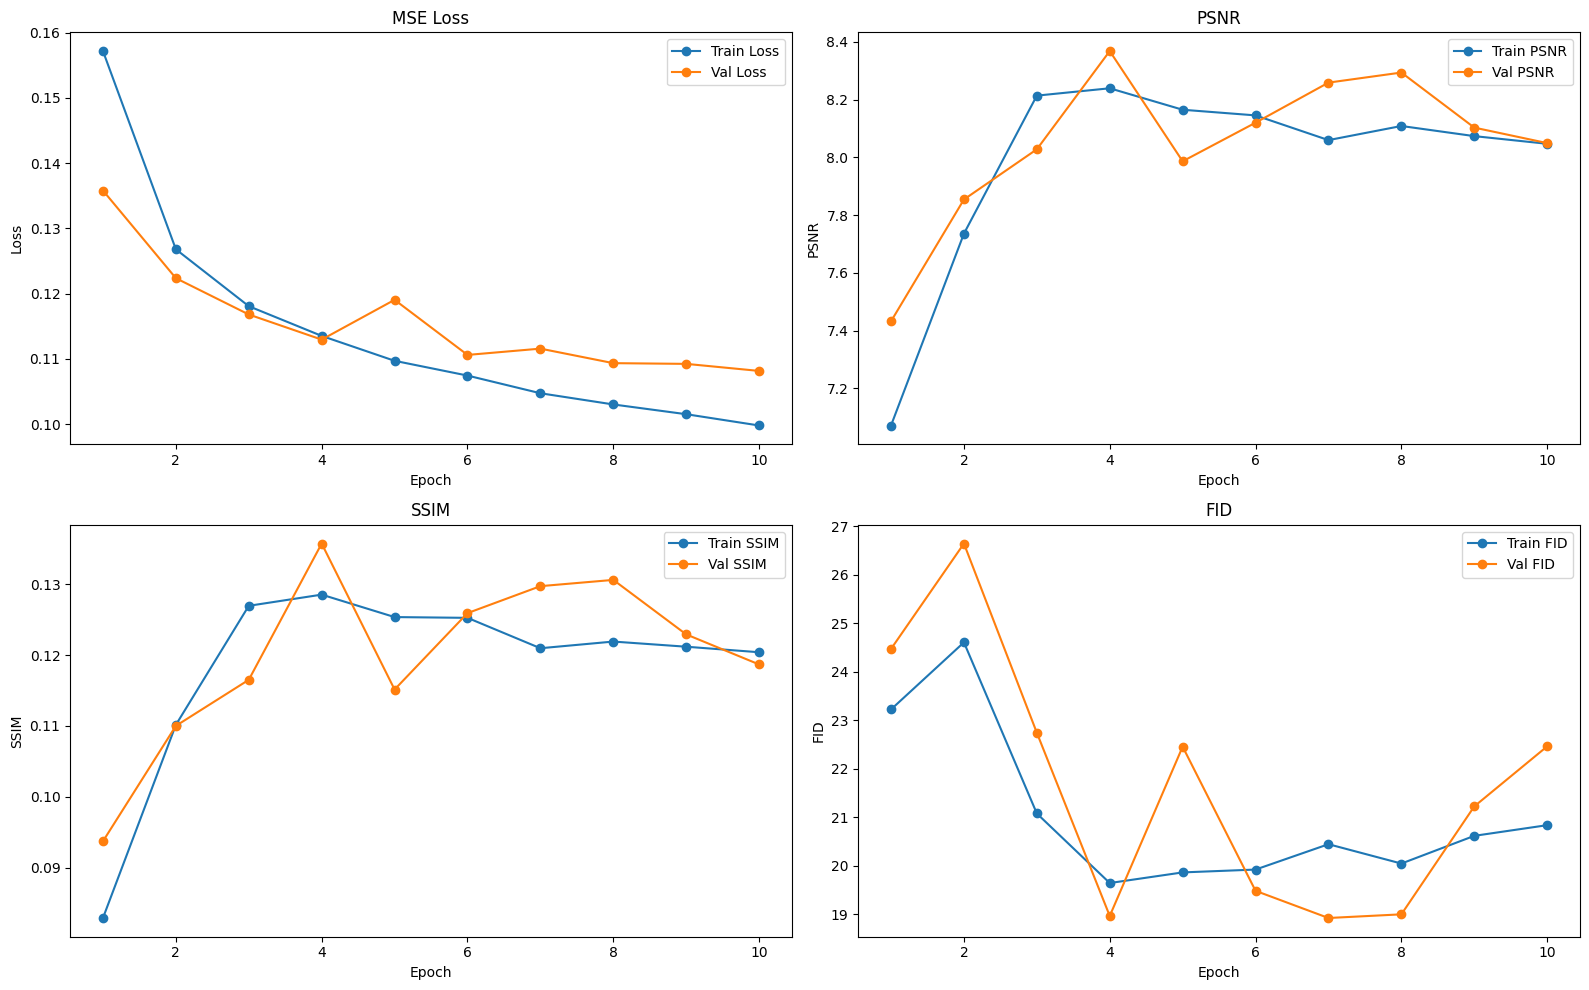

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses)+1)
plt.figure(figsize=(16,10))

# Loss
plt.subplot(2,2,1)
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses, marker='o', label='Val Loss')
plt.title("MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# PSNR
plt.subplot(2,2,2)
plt.plot(epochs_range, train_psnrs, marker='o', label='Train PSNR')
plt.plot(epochs_range, val_psnrs, marker='o', label='Val PSNR')
plt.title("PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR")
plt.legend()

# SSIM
plt.subplot(2,2,3)
plt.plot(epochs_range, train_ssims, marker='o', label='Train SSIM')
plt.plot(epochs_range, val_ssims, marker='o', label='Val SSIM')
plt.title("SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.legend()

# FID
plt.subplot(2,2,4)
plt.plot(epochs_range, train_fids, marker='o', label='Train FID')
plt.plot(epochs_range, val_fids, marker='o', label='Val FID')
plt.title("FID")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.legend()

plt.tight_layout()
plt.show()


# Save fine tuned pipeline from base pipeline and fine tuned UNet

In [ ]:
from pathlib import Path
from diffusers.utils import is_safetensors_available

# Ensure the directory exists
unet_dir = Path(INPAINT_PIPELINE_DIR) / "unet"
unet_dir.mkdir(parents=True, exist_ok=True)

# Load checkpoint UNet
best_unet_state = torch.load(inpaint_ckpt_path, map_location="cpu")

# Clean UNet keys
clean_state = {k.replace("base_model.model.", ""): v for k, v in best_unet_state.items()}

# Apply to pipeline
inpaint_base_pipe.unet.load_state_dict(clean_state, strict=False)
print("Loaded best Inpainting UNet successfully.")

# Save UNet as safetensors if available
if is_safetensors_available():
    inpaint_base_pipe.unet.save_pretrained(unet_dir, safe_serialization=True)
    print(f"Saved UNet weights as safetensors to: {unet_dir}")
else:
    # fallback to .bin
    inpaint_base_pipe.unet.save_pretrained(unet_dir)
    print(f"Safetensors not available, saved UNet as pytorch_model.bin to: {unet_dir}")

# Save full pipeline (optional)
inpaint_base_pipe.save_pretrained(INPAINT_PIPELINE_DIR)
print(f"Saved full pipeline to: {INPAINT_PIPELINE_DIR}")

Loaded best Inpainting UNet successfully.
Saved UNet weights as safetensors to: /content/drive/MyDrive/AAI-521 Final Project/fine_tuned_models/inpainting/inpainting_pipeline/unet
Saved full pipeline to: /content/drive/MyDrive/AAI-521 Final Project/fine_tuned_models/inpainting/inpainting_pipeline


In [ ]:
from tqdm import trange
import time

for i in trange(1*60, desc="Waiting 1 minute for pipeline to upload"):
    time.sleep(1)

print("15 minutes passed, continuing...")


Waiting 1 minute for pipeline to upload: 100%|██████████| 60/60 [01:00<00:00,  1.00s/it]

15 minutes passed, continuing...


# Test images with base and fine tuned model

In [7]:
# Re-Load ORIGINAL base model again (clean)
inpaint_base_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    safety_checker = None # Disabled to avoid false errors with proper usage
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'diffusers.pipelin

In [8]:

# Load fine-tuned pipeline
ft_inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    INPAINT_PIPELINE_DIR,
    image_encoder = None, # Not available for this model
    safety_checker = None # Disabled to avoid false errors with proper usage
)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


# Test set with metrics:

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

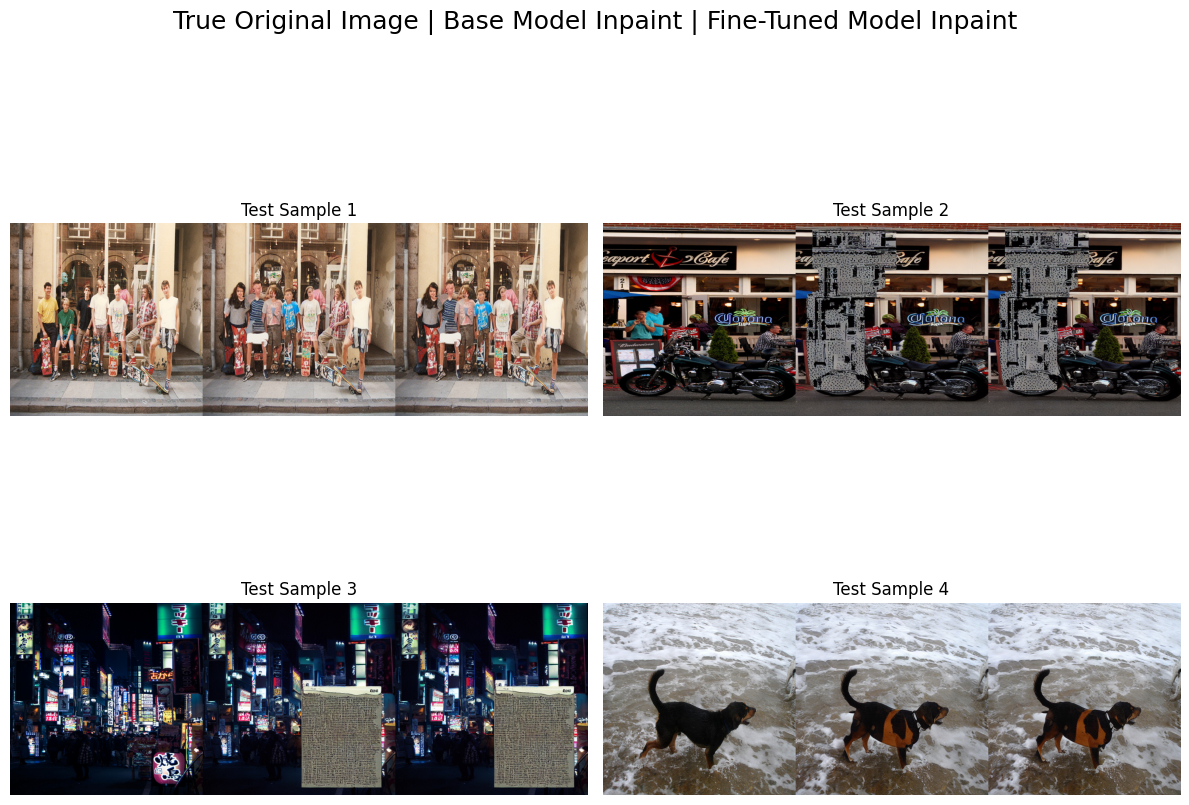


===== Inpainting Evaluation Results (4 Images per Model) =====
Base Model =>  MSE: 0.0327 | PSNR: 15.6623 | SSIM: 0.5337 | FID: 186.7641
Fine-Tuned => MSE: 0.0327 | PSNR: 15.6623 | SSIM: 0.5337 | FID: 186.7641


In [12]:
import os
import cv2
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from torchmetrics.image.fid import FrechetInceptionDistance
import matplotlib.pyplot as plt

# --------------------------
# SETTINGS
# --------------------------
resize_shape = (512, 512)
to_tensor = transforms.ToTensor()
device = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------
# IMAGE UTILS
# --------------------------
def resize_before(pil_img):
    if pil_img.mode != "RGB":
        pil_img = pil_img.convert("RGB")
    return pil_img.resize(resize_shape)

# --------------------------
# LOAD TEST IMAGES (masked + original)
# --------------------------
test_mask_dir = os.path.join(INPAINT_SPLIT_DIRS["test"], "masked")
test_orig_dir = os.path.join(INPAINT_SPLIT_DIRS["test"], "original")
test_files = sorted(os.listdir(test_mask_dir))[:4]

dataset_masked_imgs = []
dataset_original_imgs = []
dataset_binary_masks = []

for f in test_files:
    # Load images
    orig = Image.open(os.path.join(test_orig_dir, f)).convert("RGB")
    masked = Image.open(os.path.join(test_mask_dir, f)).convert("RGB")

    orig_resized = resize_before(orig)
    masked_resized = resize_before(masked)

    dataset_original_imgs.append(orig_resized)

    # --- Create mask of differing pixels ---
    masked_arr = np.array(masked_resized)
    orig_arr = np.array(orig_resized)
    mask_arr = ((orig_arr != masked_arr).any(axis=2)).astype(np.uint8) * 255

    # --- Fill masked area with white ---
    masked_arr[mask_arr == 255] = [255, 255, 255]
    filled_masked_img = Image.fromarray(masked_arr)
    dataset_masked_imgs.append(filled_masked_img)

    # --- Convert mask to single-channel L and store ---
    binary_mask = Image.fromarray(mask_arr).convert("L")
    dataset_binary_masks.append(binary_mask)

# --------------------------
# RUN MODEL INPAINTING
# --------------------------
def run_inpaint(pipe, masked_imgs, masks):
    preds = []
    for img, mask in zip(masked_imgs, masks):
        output = pipe(
            prompt=inpaint_prompt,
            image=img,
            mask_image=mask,  # use binary mask
            generator=torch.manual_seed(42)
        ).images[0]
        preds.append(resize_before(output))
    return preds

# Base and fine-tuned models
base_predictions = run_inpaint(inpaint_base_pipe, dataset_masked_imgs, dataset_binary_masks)
ft_predictions   = run_inpaint(ft_inpaint_pipe, dataset_masked_imgs, dataset_binary_masks)

# --------------------------
# METRICS
# --------------------------
def evaluate_set(gt_imgs, pred_imgs):
    mse_scores, psnr_scores, ssim_scores = [], [], []
    for gt, pred in zip(gt_imgs, pred_imgs):
        gt_t = to_tensor(gt).unsqueeze(0).to(device)
        pred_t = to_tensor(pred).unsqueeze(0).to(device)

        # MSE
        mse_scores.append(torch.mean((gt_t - pred_t) ** 2).item())
        # PSNR
        psnr_scores.append(psnr(gt_t.cpu().numpy().squeeze().transpose(1,2,0),
                                pred_t.cpu().numpy().squeeze().transpose(1,2,0), data_range=1))
        # SSIM
        ssim_scores.append(ssim(gt_t.cpu().numpy().squeeze().transpose(1,2,0),
                                pred_t.cpu().numpy().squeeze().transpose(1,2,0),
                                channel_axis=2, data_range=1))
    return np.mean(mse_scores), np.mean(psnr_scores), np.mean(ssim_scores)

mse_base, psnr_base, ssim_base = evaluate_set(dataset_original_imgs, base_predictions)
mse_ft, psnr_ft, ssim_ft       = evaluate_set(dataset_original_imgs, ft_predictions)

# --------------------------
# FID
# --------------------------
fid_metric = FrechetInceptionDistance(feature=2048).to(device)

def compute_fid(gt_imgs, pred_imgs):
    fid_metric.reset()
    for gt, pred in zip(gt_imgs, pred_imgs):
        gt_t = torch.from_numpy(np.array(gt)).permute(2,0,1).unsqueeze(0).to(torch.uint8).to(device)
        pred_t = torch.from_numpy(np.array(pred)).permute(2,0,1).unsqueeze(0).to(torch.uint8).to(device)
        fid_metric.update(gt_t, real=True)
        fid_metric.update(pred_t, real=False)
    return fid_metric.compute().item()

fid_base = compute_fid(dataset_original_imgs, base_predictions)
fid_ft   = compute_fid(dataset_original_imgs, ft_predictions)

# --------------------------
# SIDE-BY-SIDE SUBPLOTS
# --------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("True Original Image | Base Model Inpaint | Fine-Tuned Model Inpaint", fontsize=18, y=0.98)

positions = [(0,0), (0,1), (1,0), (1,1)]

for idx, (row, col) in enumerate(positions):
    if idx >= len(dataset_original_imgs):
        axes[row][col].axis("off")
        continue
    combined = np.hstack([
        cv2.cvtColor(np.array(dataset_original_imgs[idx]), cv2.COLOR_RGB2BGR),
        cv2.cvtColor(np.array(base_predictions[idx]), cv2.COLOR_RGB2BGR),
        cv2.cvtColor(np.array(ft_predictions[idx]), cv2.COLOR_RGB2BGR)
    ])
    axes[row][col].imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
    axes[row][col].axis("off")
    axes[row][col].set_title(f"Test Sample {idx+1}")

plt.tight_layout()
plt.show()

# --------------------------
# RESULTS OUTPUT
# --------------------------
print("\n===== Inpainting Evaluation Results (4 Images per Model) =====")
print(f"Base Model =>  MSE: {mse_base:.4f} | PSNR: {psnr_base:.4f} | SSIM: {ssim_base:.4f} | FID: {fid_base:.4f}")
print(f"Fine-Tuned => MSE: {mse_ft:.4f} | PSNR: {psnr_ft:.4f} | SSIM: {ssim_ft:.4f} | FID: {fid_ft:.4f}")
